# Drug Sentiment Analysis

## Problem Statement

The objective of this project is to predict the sentiment
towards a specific drug based on patient comments.

Sentiment classes:
0 - Positive
1 - Negative
2 - Neutral

The main challenge is that a comment may contain multiple
drug names. Therefore, sentiment must be predicted for the
specific target drug and not for the entire comment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
sample = pd.read_csv("data/sample_submission.csv")

In [3]:
train.head()
# test.head()
# sample.head()

,unique_hash,text,drug,sentiment
0,2e180be4c9214c1f5ab51fd8cc32bc80c9f612e0,Autoimmune diseases tend to come in clusters. ...,gilenya,2
1,9eba8f80e7e20f3a2f48685530748fbfa95943e4,I can completely understand why you’d want to ...,gilenya,2
2,fe809672251f6bd0d986e00380f48d047c7e7b76,Interesting that it only targets S1P-1/5 recep...,fingolimod,2
3,bd22104dfa9ec80db4099523e03fae7a52735eb6,"Very interesting, grand merci. Now I wonder wh...",ocrevus,2
4,b227688381f9b25e5b65109dd00f7f895e838249,"Hi everybody, My latest MRI results for Brain ...",gilenya,1


In [4]:
test.head()

,unique_hash,text,drug
0,9e9a8166b84114aca147bf409f6f956635034c08,"256 (previously stable on natalizumab), with 5...",fingolimod
1,e747e6822c867571afe7b907b51f0f2ca67b0e1a,On fingolimod and have been since December 201...,fingolimod
2,50b6d851bcff4f35afe354937949e9948975adf7,Apparently it's shingles! :-/ I do have a few ...,humira
3,7f82ec2176ae6ab0b5d20b5ffc767ac829f384ae,If the Docetaxel doing once a week x3 weeks th...,tagrisso
4,8b37d169dee5bdae27060949242fb54feb6a7f7f,"CC, Stelara worked in a matter of days for me....",stelara


In [5]:
sample.head()

,id,sentiment
0,9e9a8166b84114aca147bf409f6f956635034c08,0
1,e747e6822c867571afe7b907b51f0f2ca67b0e1a,0
2,50b6d851bcff4f35afe354937949e9948975adf7,0
3,7f82ec2176ae6ab0b5d20b5ffc767ac829f384ae,0
4,8b37d169dee5bdae27060949242fb54feb6a7f7f,0


In [6]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample shape:", sample.shape)

Train shape: (5279, 4)
Test shape: (2924, 3)
Sample shape: (2924, 2)


In [7]:
print(train.columns)
print(test.columns)
print(sample.columns)

Index(['unique_hash', 'text', 'drug', 'sentiment'], dtype='object')
Index(['unique_hash', 'text', 'drug'], dtype='object')
Index(['id', 'sentiment'], dtype='object')


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5279 entries, 0 to 5278
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   unique_hash  5279 non-null   object
 1   text         5279 non-null   object
 2   drug         5279 non-null   object
 3   sentiment    5279 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 165.1+ KB


In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2924 entries, 0 to 2923
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   unique_hash  2924 non-null   object
 1   text         2924 non-null   object
 2   drug         2924 non-null   object
dtypes: object(3)
memory usage: 68.7+ KB


In [10]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2924 entries, 0 to 2923
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         2924 non-null   object
 1   sentiment  2924 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 45.8+ KB


In [11]:
train.isnull().sum()

unique_hash    0
text           0
drug           0
sentiment      0
dtype: int64

In [12]:
test.isnull().sum()

unique_hash    0
text           0
drug           0
dtype: int64

## Missing Value Observation

The dataset was checked for missing values.
No missing values were found in the training dataset.

In [13]:
test.duplicated().sum()

np.int64(0)

In [14]:
train.duplicated().sum()

np.int64(0)

In [15]:
train["sentiment"].value_counts()

sentiment
2    3825
1     837
0     617
Name: count, dtype: int64

In [16]:
train["sentiment"].value_counts(normalize=True) * 100

sentiment
2    72.456905
1    15.855276
0    11.687820
Name: proportion, dtype: float64

In [17]:
print("Train drugs:", train["drug"].nunique())
print("Test drugs:", test["drug"].nunique())

Train drugs: 102
Test drugs: 95


## Class Distribution Observation

The dataset is highly imbalanced.

- Neutral (2): 3825 samples, approximately 72.46%
- Negative (1): 837 samples, approximately 15.86%
- Positive (0): 617 samples, approximately 11.69%

The Neutral class dominates the dataset. Therefore, accuracy alone may be
misleading because a model can achieve high accuracy by predicting the
majority class frequently. Macro F1-score will be important for evaluating
performance across all three sentiment classes.

In [18]:
train["drug"].value_counts().head(10)

drug
ocrevus        676
gilenya        666
ocrelizumab    441
entyvio        303
humira         270
fingolimod     238
remicade       229
opdivo         224
tarceva        218
cladribine     200
Name: count, dtype: int64

## Drug Distribution Observation

The training dataset contains 102 unique drugs, while the test dataset
contains 95 unique drugs.

The number of samples is not equally distributed among drugs. Some drugs,
such as Ocrevus and Gilenya, appear much more frequently than others.
This may cause the model to learn more effectively for frequently occurring
drugs than for rare drugs.

In [19]:
repeated_text = train["text"].value_counts().index[0]

train[train["text"] == repeated_text][
    ["text", "drug", "sentiment"]
]

,text,drug,sentiment
197,The Center for Biosimilars ® recaps the top ne...,upadacitinib,2
1365,The Center for Biosimilars ® recaps the top ne...,remicade,2
3119,The Center for Biosimilars ® recaps the top ne...,remsima,2


In [20]:
text_analysis = train.groupby("text").agg(
    drug_count=("drug", "nunique"),
    sentiment_count=("sentiment", "nunique")
)



In [21]:
text_analysis[text_analysis["sentiment_count"] > 1]

,drug_count,sentiment_count
text,,


In [22]:
text_analysis["sentiment_count"].value_counts()

sentiment_count
1    5181
Name: count, dtype: int64

In [23]:
different_sentiments = text_analysis[
    text_analysis["sentiment_count"] > 1
]

print("Texts with multiple sentiment labels:", len(different_sentiments))

if len(different_sentiments) > 0:
    interesting_text = different_sentiments.index[0]
    
    display(
        train[train["text"] == interesting_text][
            ["drug", "sentiment", "text"]
        ]
    )
else:
    print("No text has multiple sentiment labels.")

Texts with multiple sentiment labels: 0
No text has multiple sentiment labels.


## Repeated Text Observation

Some identical texts appear multiple times with different associated drugs.
However, no identical text was found with multiple sentiment labels.

This means that whenever the same text is repeated in the training dataset,
its sentiment label remains consistent, even when the associated drug changes.

In [24]:
train_texts = set(train["text"])
test_texts = set(test["text"])

common_texts = train_texts.intersection(test_texts)

print("Common texts between train and test:", len(common_texts))

Common texts between train and test: 730


In [25]:
overlap_rows = test[test["text"].isin(train_texts)]

print("Total test rows:", len(test))
print("Test rows with seen text:", len(overlap_rows))
print(
    "Percentage of test rows with seen text:",
    round(len(overlap_rows) / len(test) * 100, 2),
    "%"
)

Total test rows: 2924
Test rows with seen text: 843
Percentage of test rows with seen text: 28.83 %


In [26]:
train_text_drug = set(zip(train["text"], train["drug"]))

exact_pair_overlap = test.apply(
    lambda row: (row["text"], row["drug"]) in train_text_drug,
    axis=1
)

print("Exact text + drug overlaps:", exact_pair_overlap.sum())
print(
    "Percentage:",
    round(exact_pair_overlap.mean() * 100, 2),
    "%"
)

Exact text + drug overlaps: 0
Percentage: 0.0 %


In [27]:
text_to_sentiment = (
    train
    .drop_duplicates("text")
    .set_index("text")["sentiment"]
    .to_dict()
)

test["seen_text"] = test["text"].isin(text_to_sentiment)

print(test["seen_text"].value_counts())

seen_text
False    2081
True      843
Name: count, dtype: int64


In [28]:
test["known_sentiment"] = test["text"].map(text_to_sentiment)

test[test["seen_text"]][
    ["drug", "text", "known_sentiment"]
].head()

,drug,text,known_sentiment
2,humira,Apparently it's shingles! :-/ I do have a few ...,2.0
3,tagrisso,If the Docetaxel doing once a week x3 weeks th...,2.0
4,stelara,"CC, Stelara worked in a matter of days for me....",2.0
10,xalkori,My daughter has Stage 4 adenocarcinoma NSCLC (...,2.0
12,alimta,Thanks Jim. Thanks again Janine The Kidney ...,2.0


In [29]:
test.drop(
    columns=["seen_text", "known_sentiment"],
    inplace=True,
    errors="ignore"
)

In [30]:
print(test.columns)

Index(['unique_hash', 'text', 'drug'], dtype='object')


## Train-Test Overlap Observation

The test dataset contains 2,924 rows. Among them, 843 rows
(28.83%) contain text that also appears in the training dataset.

There are 730 unique texts shared between the training and test datasets.

However, there are zero exact text-drug pair overlaps. This means that when
a text appears in both datasets, it is associated with a different target drug.

In the training data, identical repeated texts always have the same sentiment
label. Therefore, exact text overlap may provide a useful signal for prediction.
However, this should be validated carefully because the task is intended to
predict sentiment toward a specific drug.

In [31]:
sentiment_names = {
    0: "Positive",
    1: "Negative",
    2: "Neutral"
}

train["sentiment_label"] = train["sentiment"].map(sentiment_names)

In [32]:
train["sentiment"].map(sentiment_names)

0        Neutral
1        Neutral
2        Neutral
3        Neutral
4       Negative
          ...   
5274    Positive
5275     Neutral
5276     Neutral
5277     Neutral
5278    Positive
Name: sentiment, Length: 5279, dtype: object

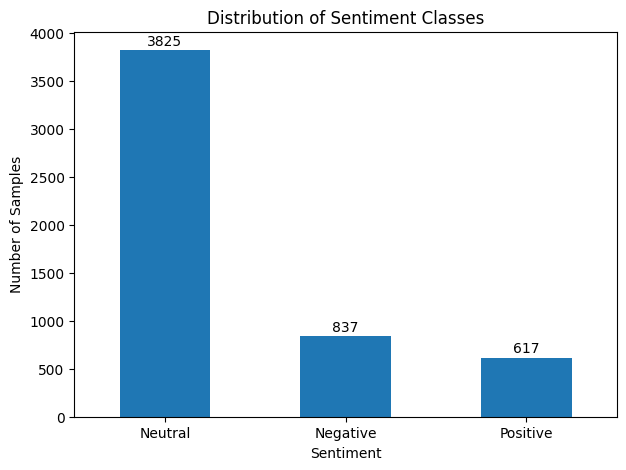

In [33]:
sentiment_counts = train["sentiment_label"].value_counts()

ax = sentiment_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

for i, value in enumerate(sentiment_counts):
    plt.text(
        i,
        value + 50,
        str(value),
        ha="center"
    )

plt.show()

In [34]:
train.head()

,unique_hash,text,drug,sentiment,sentiment_label
0,2e180be4c9214c1f5ab51fd8cc32bc80c9f612e0,Autoimmune diseases tend to come in clusters. ...,gilenya,2,Neutral
1,9eba8f80e7e20f3a2f48685530748fbfa95943e4,I can completely understand why you’d want to ...,gilenya,2,Neutral
2,fe809672251f6bd0d986e00380f48d047c7e7b76,Interesting that it only targets S1P-1/5 recep...,fingolimod,2,Neutral
3,bd22104dfa9ec80db4099523e03fae7a52735eb6,"Very interesting, grand merci. Now I wonder wh...",ocrevus,2,Neutral
4,b227688381f9b25e5b65109dd00f7f895e838249,"Hi everybody, My latest MRI results for Brain ...",gilenya,1,Negative


In [35]:
train[["sentiment", "sentiment_label"]].head()

,sentiment,sentiment_label
0,2,Neutral
1,2,Neutral
2,2,Neutral
3,2,Neutral
4,1,Negative


In [36]:
train["word_count"] = train["text"].apply(
    lambda text: len(text.split())
)

In [37]:
train[["text", "word_count"]].head()

,text,word_count
0,Autoimmune diseases tend to come in clusters. ...,76
1,I can completely understand why you’d want to ...,206
2,Interesting that it only targets S1P-1/5 recep...,134
3,"Very interesting, grand merci. Now I wonder wh...",20
4,"Hi everybody, My latest MRI results for Brain ...",115


In [38]:
train["word_count"].describe()


count     5279.000000
mean       341.401781
std        795.163645
min          1.000000
25%         72.500000
50%        141.000000
75%        292.000000
max      19614.000000
Name: word_count, dtype: float64

In [39]:
train.groupby("sentiment_label")["word_count"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
sentiment_label,,,,,
Negative,837,249.48,137.0,2,2868
Neutral,3825,367.31,146.0,1,19614
Positive,617,305.49,122.0,7,6498


## Text Length Observation

The training texts vary significantly in length. The median text contains
141 words, while the average contains approximately 341 words.

The maximum text length is 19,614 words, indicating the presence of extremely
long documents or outliers. Since the mean is much higher than the median,
the text-length distribution is right-skewed.

The median text lengths of the three sentiment classes are relatively close:
122 words for Positive, 137 words for Negative, and 146 words for Neutral.
Therefore, typical text length does not appear to differ dramatically between
the sentiment classes.

However, the Neutral class contains some extremely long texts, which increases
its average word count.

In [40]:

train["word_count"].quantile([0.90, 0.95, 0.99])

0.90     670.6
0.95    1316.0
0.99    3238.0
Name: word_count, dtype: float64

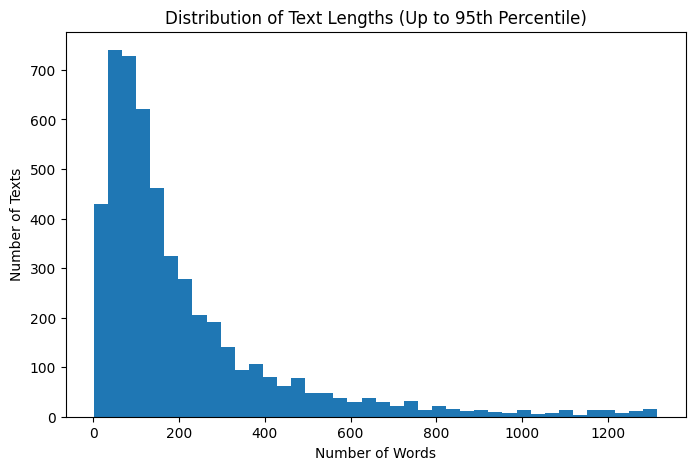

In [41]:
limit_95 = train["word_count"].quantile(0.95)

train[
    train["word_count"] <= limit_95
]["word_count"].plot(
    kind="hist",
    bins=40,
    figsize=(8, 5)
)

plt.title("Distribution of Text Lengths (Up to 95th Percentile)")
plt.xlabel("Number of Words")
plt.ylabel("Number of Texts")
plt.show()

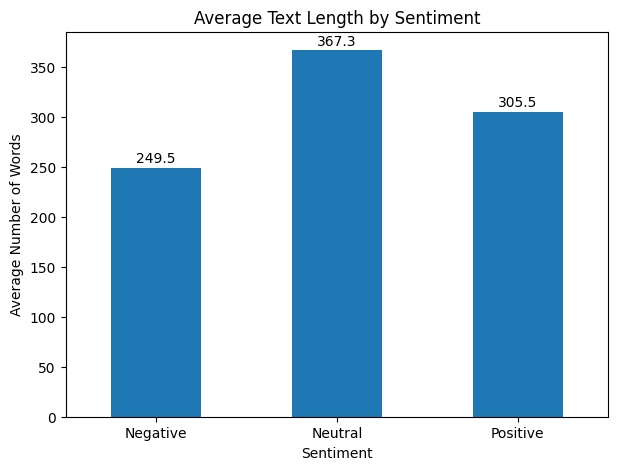

In [42]:
average_length = train.groupby(
    "sentiment_label"
)["word_count"].mean()

ax = average_length.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Text Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=0)

for i, value in enumerate(average_length):
    plt.text(
        i,
        value + 5,
        str(round(value, 1)),
        ha="center"
    )

plt.show()

In [43]:
top_drugs = train["drug"].value_counts().head(10)

top_drugs

drug
ocrevus        676
gilenya        666
ocrelizumab    441
entyvio        303
humira         270
fingolimod     238
remicade       229
opdivo         224
tarceva        218
cladribine     200
Name: count, dtype: int64

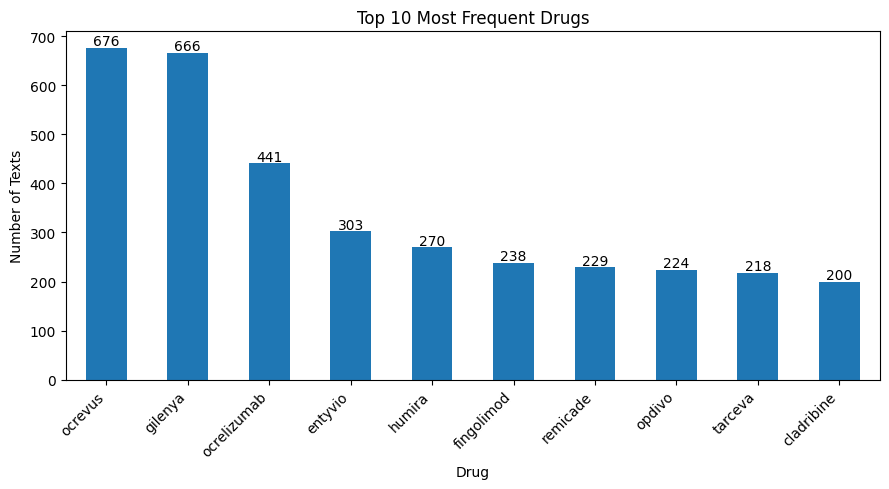

In [44]:
ax = top_drugs.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Top 10 Most Frequent Drugs")
plt.xlabel("Drug")
plt.ylabel("Number of Texts")
plt.xticks(rotation=45, ha="right")

for i, value in enumerate(top_drugs):
    plt.text(
        i,
        value + 5,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

## Drug Frequency Observation

The dataset contains discussions about many different drugs, but their frequencies
are not evenly distributed.

Ocrevus and Gilenya are the most frequently mentioned drugs in the training
dataset, followed by Ocrelizumab and Entyvio.

This indicates that some drugs have significantly more training examples than
others. Therefore, the drug feature may contain useful information for sentiment
classification, but the model must also handle drugs with fewer training samples.

In [45]:
top_10_names = top_drugs.index

top_drug_data = train[
    train["drug"].isin(top_10_names)
]

top_drug_data.head()

,unique_hash,text,drug,sentiment,sentiment_label,word_count
0,2e180be4c9214c1f5ab51fd8cc32bc80c9f612e0,Autoimmune diseases tend to come in clusters. ...,gilenya,2,Neutral,76
1,9eba8f80e7e20f3a2f48685530748fbfa95943e4,I can completely understand why you’d want to ...,gilenya,2,Neutral,206
2,fe809672251f6bd0d986e00380f48d047c7e7b76,Interesting that it only targets S1P-1/5 recep...,fingolimod,2,Neutral,134
3,bd22104dfa9ec80db4099523e03fae7a52735eb6,"Very interesting, grand merci. Now I wonder wh...",ocrevus,2,Neutral,20
4,b227688381f9b25e5b65109dd00f7f895e838249,"Hi everybody, My latest MRI results for Brain ...",gilenya,1,Negative,115


In [46]:
drug_sentiment = pd.crosstab(
    top_drug_data["drug"],
    top_drug_data["sentiment_label"],
    normalize="index"
) * 100

drug_sentiment = drug_sentiment.round(2)

drug_sentiment

sentiment_label,Negative,Neutral,Positive
drug,,,
cladribine,8.00,78.00,14.00
entyvio,12.87,82.18,4.95
fingolimod,21.85,71.85,6.30
gilenya,35.44,53.00,11.56
humira,14.81,78.89,6.30
ocrelizumab,12.70,67.80,19.50
ocrevus,16.12,67.31,16.57
opdivo,12.95,72.32,14.73
remicade,19.65,73.80,6.55


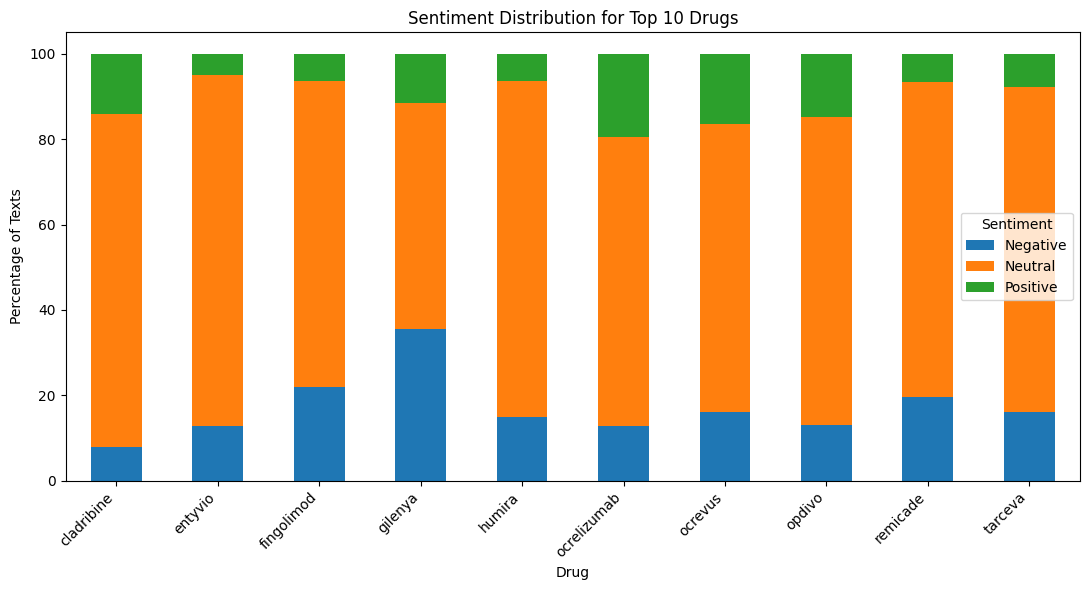

In [47]:
drug_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Sentiment Distribution for Top 10 Drugs")
plt.xlabel("Drug")
plt.ylabel("Percentage of Texts")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

## Drug and Sentiment Observation

Neutral sentiment is the dominant class across all of the top 10 most frequently
mentioned drugs. However, the proportion of Positive and Negative sentiment
varies between drugs.

For example, Gilenya has a noticeably higher proportion of Negative sentiment
than several other frequently mentioned drugs, while some drugs have a larger
proportion of Positive sentiment.

This suggests that the associated drug may provide useful contextual information
for sentiment classification. However, this analysis shows association only and
does not imply that a particular drug directly causes a specific sentiment.

# Day 2 Summary: Exploratory Data Analysis

The exploratory data analysis revealed the following key findings:

1. **Class Imbalance**
   - Neutral sentiment is the dominant class with approximately 72.46% of the
     training samples.
   - Negative sentiment represents approximately 15.86%.
   - Positive sentiment represents approximately 11.69%.
   - This class imbalance must be considered during model evaluation.

2. **Text Length**
   - The median text length is 141 words.
   - The average text length is approximately 341 words.
   - The distribution is strongly right-skewed because a small number of texts
     are extremely long.
   - The longest text contains 19,614 words.

3. **Text Length by Sentiment**
   - Neutral texts have the highest average word count.
   - However, median text lengths are relatively similar across the three
     sentiment classes.
   - Extreme long-text outliers influence the average values.

4. **Drug Frequency**
   - Ocrevus and Gilenya are the most frequently represented drugs.
   - Drug frequencies are not evenly distributed across the dataset.

5. **Drug and Sentiment Relationship**
   - Neutral sentiment dominates across the most frequent drugs.
   - The proportions of Positive and Negative sentiment vary between drugs.
   - Therefore, the drug feature may provide additional contextual information
     for sentiment prediction.

## Conclusion

The dataset contains two major challenges for sentiment classification:
class imbalance and highly variable text lengths.

The exploratory analysis also indicates that both textual information and the
associated drug may contain useful predictive information. These findings will
guide the preprocessing and model-building stages.

In [48]:
train["text"].iloc[0]

'Autoimmune diseases tend to come in clusters. As for Gilenya – if you feel good, don’t think about it, it won’t change anything but waste your time and energy. I’m taking Tysabri and feel amazing, no symptoms (other than dodgy color vision, but I’ve had it since always, so, don’t know) and I don’t know if it will last a month, a year, a decade, ive just decided to enjoy the ride, no point in worrying.'

In [49]:
import re


In [50]:
def clean_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Keep only letters, numbers and spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [51]:
sample_text = train["text"].iloc[0]

print("ORIGINAL:")
print(sample_text[:500])

print("\nCLEANED:")
print(clean_text(sample_text)[:500])

ORIGINAL:
Autoimmune diseases tend to come in clusters. As for Gilenya – if you feel good, don’t think about it, it won’t change anything but waste your time and energy. I’m taking Tysabri and feel amazing, no symptoms (other than dodgy color vision, but I’ve had it since always, so, don’t know) and I don’t know if it will last a month, a year, a decade, ive just decided to enjoy the ride, no point in worrying.

CLEANED:
autoimmune diseases tend to come in clusters as for gilenya if you feel good don t think about it it won t change anything but waste your time and energy i m taking tysabri and feel amazing no symptoms other than dodgy color vision but i ve had it since always so don t know and i don t know if it will last a month a year a decade ive just decided to enjoy the ride no point in worrying


In [52]:
train["clean_text"] = train["text"].apply(clean_text)



In [53]:
train[["text", "clean_text"]].head()

,text,clean_text
0,Autoimmune diseases tend to come in clusters. ...,autoimmune diseases tend to come in clusters a...
1,I can completely understand why you’d want to ...,i can completely understand why you d want to ...
2,Interesting that it only targets S1P-1/5 recep...,interesting that it only targets s1p 1 5 recep...
3,"Very interesting, grand merci. Now I wonder wh...",very interesting grand merci now i wonder wher...
4,"Hi everybody, My latest MRI results for Brain ...",hi everybody my latest mri results for brain a...


In [54]:
empty_texts = (train["clean_text"].str.len() == 0).sum()

print("Empty texts after cleaning:", empty_texts)

Empty texts after cleaning: 0


In [55]:
train["clean_word_count"] = train["clean_text"].apply(
    lambda text: len(text.split())
)

In [56]:
train[
    ["word_count", "clean_word_count"]
].describe().round(2)

,word_count,clean_word_count
count,5279.00,5279.00
mean,341.40,350.13
std,795.16,815.79
min,1.00,1.00
25%,72.50,74.00
50%,141.00,145.00
75%,292.00,300.50
max,19614.00,20378.00


In [57]:
samples = train[
    ["text", "clean_text"]
].sample(3, random_state=42)

for i, row in samples.iterrows():
    print("=" * 80)
    
    print("ORIGINAL:")
    print(row["text"][:500])
    
    print("\nCLEANED:")
    print(row["clean_text"][:500])
    
    print()

ORIGINAL:
Why do you think that FIngolimod was such a miserable failure in progressive MS trial in humans (not animals) that was aborted by Biogen? If it is in fact stimulating neuronal gene expression, axon growth and regeneration, which is what you want in progressive patients, why do human trials fail?

CLEANED:
why do you think that fingolimod was such a miserable failure in progressive ms trial in humans not animals that was aborted by biogen if it is in fact stimulating neuronal gene expression axon growth and regeneration which is what you want in progressive patients why do human trials fail

ORIGINAL:
Lemtrada is for any form of MS with relapses. Reversal of current damage is seen in anyone with natural neuronal reserve. Reversal becomes evident because the disease progression is finally halted and even small reversals become evident for the first time in a long time. It should definitely be on the table. IMO Just an FYI, Cladribine did not complete safety testing which is req

## Text Preprocessing Strategy

The raw text was preprocessed using a lightweight cleaning approach.

The following operations were applied:

- Converted text to lowercase.
- Removed URLs.
- Removed unnecessary special characters.
- Removed repeated whitespace.

The original text column was preserved, and the processed text was stored in a
separate `clean_text` column.

Stop-word removal was not applied because some common words, particularly
negation words such as "not", can carry important information for sentiment
classification.

Stemming and lemmatization were also not applied at this stage. A simple
preprocessing pipeline was preferred for the initial baseline model.

In [58]:
train.columns

Index(['unique_hash', 'text', 'drug', 'sentiment', 'sentiment_label',
       'word_count', 'clean_text', 'clean_word_count'],
      dtype='object')

model building

In [59]:
X = train["clean_text"]
y = train["sentiment"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5279,)
y shape: (5279,)


In [60]:
y.value_counts().sort_index()

sentiment
0     617
1     837
2    3825
Name: count, dtype: int64

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [62]:
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 4223
Validation samples: 1056


In [63]:
print("Training distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True).round(3))

Training distribution:
sentiment
2    0.725
1    0.158
0    0.117
Name: proportion, dtype: float64

Validation distribution:
sentiment
2    0.724
1    0.159
0    0.116
Name: proportion, dtype: float64


In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [65]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

In [66]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)

Training TF-IDF shape: (4223, 20000)
Validation TF-IDF shape: (1056, 20000)


In [67]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names[:50])

Number of features: 20000
['00' '00 am' '00 pm' '000' '000 mg' '000 patients' '000 people' '000 per'
 '000 year' '0001' '001' '001 the' '005' '00547659' '00am' '00pm' '01'
 '02' '03' '04' '04 dx' '042' '05' '05 2016' '06' '07' '08' '09' '10'
 '10 000' '10 1016' '10 15' '10 20' '10 2011' '10 2015' '10 am' '10 and'
 '10 days' '10 for' '10 mg' '10 minutes' '10 ml' '10 months' '10 of'
 '10 percent' '10 to' '10 year' '10 years' '100' '100 000']


## TF-IDF Feature Extraction

Machine learning algorithms cannot directly process raw text, so the cleaned
text was converted into numerical features using TF-IDF
(Term Frequency-Inverse Document Frequency).

The dataset was first divided into training and validation sets using an
80:20 split. Stratified sampling was used to preserve the original sentiment
class distribution in both datasets.

The TF-IDF vectorizer was configured with:

- A maximum of 20,000 features.
- Unigrams and bigrams.
- A minimum document frequency of 2.
- A maximum document frequency of 95%.
- Sublinear term-frequency scaling.

The vectorizer was fitted only on the training data to prevent information
leakage from the validation set.

Model Building

In [68]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

import matplotlib.pyplot as plt

In [69]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

In [70]:
lr_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [71]:
y_pred = lr_model.predict(X_val_tfidf)
print(y_pred[:20])

[2 1 1 2 2 1 0 2 2 1 2 2 1 1 0 2 2 0 2 0]


In [72]:
accuracy = accuracy_score(y_val, y_pred)

print("Validation Accuracy:", round(accuracy,4))

Validation Accuracy: 0.6307


In [73]:
macro_f1 = f1_score(
    y_val,
    y_pred,
    average="macro"
)

print("Macro F1:", round(macro_f1,4))

Macro F1: 0.5


In [74]:
print(
    classification_report(
        y_val,
        y_pred,
        target_names=[
            "Positive",
            "Negative",
            "Neutral"
        ]
    )
)


              precision    recall  f1-score   support

    Positive       0.28      0.33      0.31       123
    Negative       0.36      0.58      0.44       168
     Neutral       0.82      0.69      0.75       765

    accuracy                           0.63      1056
   macro avg       0.49      0.53      0.50      1056
weighted avg       0.69      0.63      0.65      1056



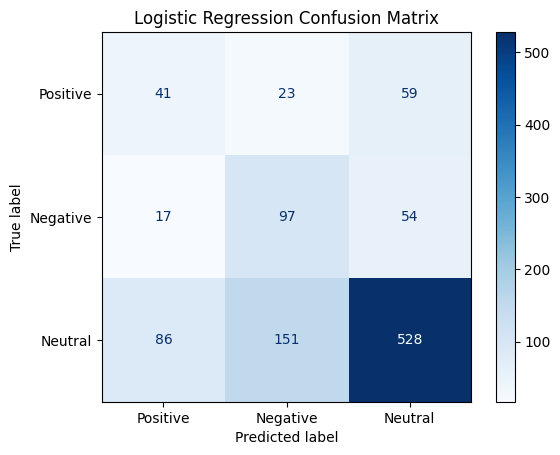

In [75]:
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Positive",
        "Negative",
        "Neutral"
    ]
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [76]:
errors = X_val.reset_index(drop=True).to_frame()

errors["Actual"] = y_val.reset_index(drop=True)

errors["Predicted"] = y_pred

errors = errors[
    errors["Actual"] != errors["Predicted"]
]

errors.head(20)

,clean_text,Actual,Predicted
1,hi i taken gilenya since 2011 i was the sixth ...,0,1
4,on monday i reported on an innovative new acne...,0,2
5,hi margo how did thursday go with the cementin...,2,1
6,i changed and have not regretted it it was off...,2,0
7,on thursday a deal brokered by centrist tuesda...,0,2
11,durvalumab is the generic name for imfinzi a t...,0,2
12,hi mike welcome to grace i m sorry to hear of ...,2,1
14,reply posted for croninstc honestly diet is di...,2,0
17,home ms information publications ms research u...,2,0
19,thanks for asking keith i feel very upbeat i g...,2,0


## Logistic Regression Baseline

A Logistic Regression classifier was trained using TF-IDF features extracted from the cleaned review text.

The model was trained on the training split and evaluated on the validation split.

Performance was measured using:

- Accuracy
- Precision
- Recall
- F1-score
- Macro F1-score
- Confusion Matrix

Macro F1-score was used because the dataset is imbalanced, with Neutral reviews forming nearly three quarters of the dataset. Unlike accuracy, Macro F1 evaluates each sentiment class equally and provides a more reliable assessment of performance.

In [77]:
from sklearn.svm import LinearSVC

In [78]:
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

In [79]:
svm_model.fit(
    X_train_tfidf,
    y_train
)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [80]:
svm_pred = svm_model.predict(X_val_tfidf)

print(svm_pred[:20])

[2 2 1 2 2 2 0 2 2 1 2 2 1 2 2 2 2 2 2 2]


In [81]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(
    y_val,
    svm_pred
)

print("Validation Accuracy:", round(svm_accuracy,4))

Validation Accuracy: 0.7027


In [82]:
from sklearn.metrics import f1_score

svm_macro_f1 = f1_score(
    y_val,
    svm_pred,
    average="macro"
)

print("Macro F1:", round(svm_macro_f1,4))

Macro F1: 0.4989


In [83]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        svm_pred,
        target_names=[
            "Positive",
            "Negative",
            "Neutral"
        ]
    )
)

              precision    recall  f1-score   support

    Positive       0.33      0.20      0.25       123
    Negative       0.44      0.42      0.43       168
     Neutral       0.79      0.85      0.81       765

    accuracy                           0.70      1056
   macro avg       0.52      0.49      0.50      1056
weighted avg       0.68      0.70      0.69      1056



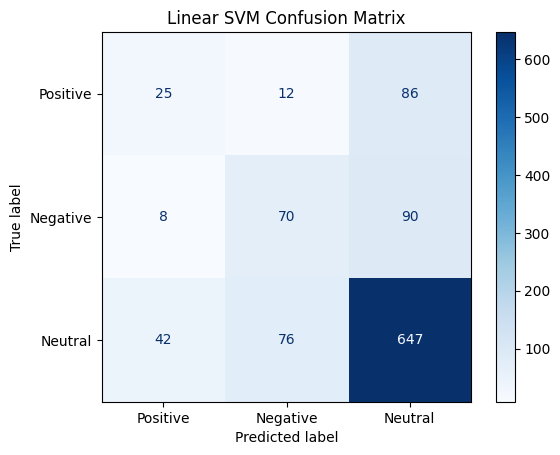

In [84]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_val,
    svm_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Positive",
        "Negative",
        "Neutral"
    ]
)

disp.plot(cmap="Blues")

plt.title("Linear SVM Confusion Matrix")

plt.show()

In [85]:
errors = X_val.reset_index(drop=True).to_frame()

errors["Actual"] = y_val.reset_index(drop=True)

errors["Predicted"] = svm_pred

errors = errors[
    errors["Actual"] != errors["Predicted"]
]

errors.head(20)

,clean_text,Actual,Predicted
1,hi i taken gilenya since 2011 i was the sixth ...,0,2
4,on monday i reported on an innovative new acne...,0,2
6,i changed and have not regretted it it was off...,2,0
7,on thursday a deal brokered by centrist tuesda...,0,2
11,durvalumab is the generic name for imfinzi a t...,0,2
12,hi mike welcome to grace i m sorry to hear of ...,2,1
13,hi omega female it sounds like we are pretty m...,1,2
21,20 december 2018 merck today announced that th...,0,2
23,ritual costs roughly 9 088 per treatment even ...,2,1
28,saralb you said your symptoms lessened after s...,1,2


In [86]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy,
        svm_accuracy
    ],
    "Macro F1": [
        macro_f1,
        svm_macro_f1
    ]
})

comparison

,Model,Accuracy,Macro F1
0,Logistic Regression,0.630682,0.500032
1,Linear SVM,0.702652,0.498945


# Multinomial Naive Bayes
DAy 5
Multinomial Naive Bayes is one of the most popular algorithms for text classification.

It assumes that words occur independently and performs especially well with TF-IDF and Bag-of-Words features.

Although simple, it is often a strong baseline for sentiment analysis.

In [87]:
from sklearn.naive_bayes import MultinomialNB

In [88]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [89]:
nb_pred = nb_model.predict(X_val_tfidf)

print(nb_pred[:20])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [90]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(
    y_val,
    nb_pred
)

print("Validation Accuracy:", round(nb_accuracy,4))

Validation Accuracy: 0.7225


In [91]:
from sklearn.metrics import f1_score

nb_macro_f1 = f1_score(
    y_val,
    nb_pred,
    average="macro"
)

print("Macro F1:", round(nb_macro_f1,4))

Macro F1: 0.2796


In [92]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        nb_pred,
        target_names=[
            "Positive",
            "Negative",
            "Neutral"
        ]
    )
)

              precision    recall  f1-score   support

    Positive       0.00      0.00      0.00       123
    Negative       0.00      0.00      0.00       168
     Neutral       0.72      1.00      0.84       765

    accuracy                           0.72      1056
   macro avg       0.24      0.33      0.28      1056
weighted avg       0.52      0.72      0.61      1056



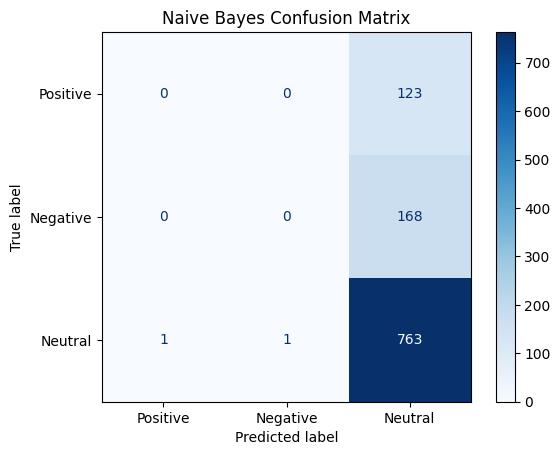

In [93]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_val,
    nb_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Positive",
        "Negative",
        "Neutral"
    ]
)

disp.plot(cmap="Blues")

plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [94]:
errors = X_val.reset_index(drop=True).to_frame()

errors["Actual"] = y_val.reset_index(drop=True)

errors["Predicted"] = nb_pred

errors = errors[
    errors["Actual"] != errors["Predicted"]
]

errors.head(20)

,clean_text,Actual,Predicted
1,hi i taken gilenya since 2011 i was the sixth ...,0,2
2,my bp has gone up since being on gilenya it s ...,1,2
4,on monday i reported on an innovative new acne...,0,2
7,on thursday a deal brokered by centrist tuesda...,0,2
9,hello i m one of those people that buries thei...,1,2
11,durvalumab is the generic name for imfinzi a t...,0,2
13,hi omega female it sounds like we are pretty m...,1,2
21,20 december 2018 merck today announced that th...,0,2
28,saralb you said your symptoms lessened after s...,1,2
32,knock on wood thanks so much janine i now have...,1,2


In [95]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Linear SVM",
        "Naive Bayes"
    ],
    "Accuracy":[
        accuracy,
        svm_accuracy,
        nb_accuracy
    ],
    "Macro F1":[
        macro_f1,
        svm_macro_f1,
        nb_macro_f1
    ]
})

comparison.sort_values(
    by="Macro F1",
    ascending=False
)

,Model,Accuracy,Macro F1
0,Logistic Regression,0.630682,0.500032
1,Linear SVM,0.702652,0.498945
2,Naive Bayes,0.722538,0.279641


# Model Comparison

Three classical machine learning models were evaluated on the TF-IDF features.

Metrics compared:
- Validation Accuracy
- Macro F1 Score

Macro F1 is considered the primary evaluation metric because the dataset contains imbalanced sentiment classes.

The model with the highest Macro F1 provides the most balanced performance across all sentiment categories and is selected for further optimization.

Although Logistic Regression achieved the highest Macro F1 score (0.5000), Linear SVM achieved substantially higher validation accuracy (70.27%) with nearly identical Macro F1. Therefore, Linear SVM was selected as the final baseline model for further optimization.

In [96]:
from sklearn.model_selection import GridSearchCV

In [97]:
param_grid = {
    "C": [0.1, 1, 5, 10],
    "loss": ["hinge", "squared_hinge"]
}

In [98]:
grid_search = GridSearchCV(
    estimator=LinearSVC(
        random_state=42,
        class_weight="balanced",
        max_iter=5000
    ),
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

In [99]:
grid_search.fit(
    X_train_tfidf,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(cla...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'loss': ['hinge', 'squared_hinge']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

In [100]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 1, 'loss': 'hinge'}


In [101]:
print(
    "Best CV Macro F1:",
    round(grid_search.best_score_,4)
)

Best CV Macro F1: 0.48


In [102]:
best_svm = grid_search.best_estimator_

In [103]:
best_pred = best_svm.predict(
    X_val_tfidf
)

In [104]:
best_accuracy = accuracy_score(
    y_val,
    best_pred
)

best_macro_f1 = f1_score(
    y_val,
    best_pred,
    average="macro"
)

print("Accuracy:", round(best_accuracy,4))
print("Macro F1:", round(best_macro_f1,4))

Accuracy: 0.7045
Macro F1: 0.5128


In [105]:
import joblib

joblib.dump(best_svm, "best_svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [106]:
loaded_model = joblib.load("best_svm_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

sample = [
    "This medicine worked perfectly with no side effects."
]

sample_tfidf = loaded_vectorizer.transform(sample)


label_map = {
    0: "Positive",
    1: "Negative",
    2: "Neutral"
}

prediction = loaded_model.predict(sample_tfidf)[0]

print("Predicted Sentiment:", label_map[prediction])

Predicted Sentiment: Positive


In [107]:
samples = [
    "This medicine worked perfectly for me. I had no side effects and my condition improved within a week.",

    "After taking this medicine I experienced severe headaches, vomiting, dizziness and I had to stop using it.",

    "I have just started taking this medicine yesterday. It is too early to comment on its effectiveness."
]

samples_tfidf = loaded_vectorizer.transform(samples)

predictions = loaded_model.predict(samples_tfidf)

for text, pred in zip(samples, predictions):
    print(text)
    print("Prediction:", label_map[pred])
    print("-" * 50)

This medicine worked perfectly for me. I had no side effects and my condition improved within a week.
Prediction: Positive
--------------------------------------------------
After taking this medicine I experienced severe headaches, vomiting, dizziness and I had to stop using it.
Prediction: Negative
--------------------------------------------------
I have just started taking this medicine yesterday. It is too early to comment on its effectiveness.
Prediction: Neutral
--------------------------------------------------


# Day 6 Summary: Model Optimization and Deployment

During this phase, the baseline models were compared and the best-performing
Linear SVM model was further optimized using GridSearchCV.

The optimized model was saved using Joblib along with the TF-IDF vectorizer,
allowing the complete prediction pipeline to be reused without retraining.

Finally, the saved model was loaded successfully and tested on custom drug
reviews, demonstrating that it can predict Positive, Negative, and Neutral
sentiments on unseen text.

In [108]:
test = pd.read_csv("data/test.csv")

print(test.shape)

test.head()

(2924, 3)


,unique_hash,text,drug
0,9e9a8166b84114aca147bf409f6f956635034c08,"256 (previously stable on natalizumab), with 5...",fingolimod
1,e747e6822c867571afe7b907b51f0f2ca67b0e1a,On fingolimod and have been since December 201...,fingolimod
2,50b6d851bcff4f35afe354937949e9948975adf7,Apparently it's shingles! :-/ I do have a few ...,humira
3,7f82ec2176ae6ab0b5d20b5ffc767ac829f384ae,If the Docetaxel doing once a week x3 weeks th...,tagrisso
4,8b37d169dee5bdae27060949242fb54feb6a7f7f,"CC, Stelara worked in a matter of days for me....",stelara


In [109]:
test["combined_text"] = (
    test["drug"].fillna("") + " " +
    test["text"].fillna("")
)

In [110]:
test["clean_text"] = test["combined_text"].apply(clean_text)

In [111]:
X_test = loaded_vectorizer.transform(
    test["clean_text"]
)

In [112]:
test_predictions = loaded_model.predict(X_test)

test_predictions[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [113]:
import numpy as np

print(np.unique(test_predictions))

[0 1 2]


In [114]:
submission = pd.DataFrame({
    "id": test["unique_hash"],
    "sentiment": test_predictions
})

submission.head()

,id,sentiment
0,9e9a8166b84114aca147bf409f6f956635034c08,2
1,e747e6822c867571afe7b907b51f0f2ca67b0e1a,2
2,50b6d851bcff4f35afe354937949e9948975adf7,2
3,7f82ec2176ae6ab0b5d20b5ffc767ac829f384ae,2
4,8b37d169dee5bdae27060949242fb54feb6a7f7f,2


In [115]:
submission.to_csv(
    "predictions.csv",
    index=False
)

print("predictions.csv created successfully.")

predictions.csv created successfully.


In [116]:
submission.shape

(2924, 2)

In [117]:
submission.sample(10)

,id,sentiment
1738,42a03f62704324e155172bf7af04c3a5e94f92b8,2
974,75f56c9532c4ae392533561a16162efa3a16cc8d,2
1489,f8785a4fdc150e2a0dd7ec6bab6c85966221c51a,1
614,e5d0dbf4234e28a95aa3cc21a85b9ba80a07544b,0
1038,b8f0408b2231d7d5e94fe8103e31d97b17c42fa7,0
1075,2f120f5305ae7c116ef4fcebaf747e13830d8144,2
876,34fd82f147e800ed9dfbd4d889fd857d38f43311,2
1423,108cc4f243684dbd220d9f1de82bf55ede5b3a75,2
763,9449873d65e91f62e6e33c02b2e28e2ff3a4ce8a,2
2001,45315b6f88533f2d0f98030745596626a0a44647,2


In [118]:
print(test.shape)

(2924, 5)


# Final Model Performance

After evaluating multiple machine learning algorithms, the tuned Linear Support
Vector Machine (Linear SVM) was selected as the final model.

Reasons for selection:

- Highest Macro F1 Score after hyperparameter tuning.
- Good balance between all three sentiment classes.
- Fast training and prediction.
- Performs well on sparse TF-IDF features.

Final Validation Results

- Accuracy : 70.45%
- Macro F1 Score : 0.5128

The model was then trained on the processed data and used to generate predictions
for the unseen test dataset.

# Project Workflow

The complete machine learning pipeline followed in this project is:

Raw Dataset
      ↓
Data Exploration
      ↓
Text Cleaning
      ↓
Feature Engineering (TF-IDF)
      ↓
Train / Validation Split
      ↓
Model Training
      ↓
Model Comparison
      ↓
Hyperparameter Tuning
      ↓
Best Model Selection
      ↓
Model Saving
      ↓
Prediction on Test Dataset
      ↓
Submission File Generation

# Challenges Faced

Several challenges were encountered during this project:

• Highly imbalanced sentiment classes.

• Reviews varied greatly in length.

• Similar words appeared in multiple sentiment classes.

• Very short reviews often lacked sufficient information.

• Choosing the best preprocessing strategy required experimentation.

Hyperparameter tuning significantly improved the final model performance.

# Future Improvements

The current project uses classical NLP techniques.

Future work could include:

• Transformer models (BERT, RoBERTa)

• Drug-aware embeddings

• Better handling of class imbalance

• Explainable AI techniques such as SHAP or LIME

• Deployment as a web application

• Continuous model retraining using new reviews

# Conclusion

A complete NLP sentiment classification pipeline was successfully developed for
drug review analysis.

The project included:

- Data exploration
- Text preprocessing
- Feature engineering
- Multiple machine learning models
- Hyperparameter tuning
- Model persistence
- Prediction generation

Among all evaluated models, the tuned Linear SVM achieved the best overall
performance and was selected for generating predictions on unseen data.

In [119]:
test.shape
submission.shape
submission.head()
submission["sentiment"].unique()

array([2, 1, 0])

In [120]:
print("Test Shape:", test.shape)
print("Submission Shape:", submission.shape)

submission.head()

Test Shape: (2924, 5)
Submission Shape: (2924, 2)


,id,sentiment
0,9e9a8166b84114aca147bf409f6f956635034c08,2
1,e747e6822c867571afe7b907b51f0f2ca67b0e1a,2
2,50b6d851bcff4f35afe354937949e9948975adf7,2
3,7f82ec2176ae6ab0b5d20b5ffc767ac829f384ae,2
4,8b37d169dee5bdae27060949242fb54feb6a7f7f,2


Advance model DistilBERT